# Analysing text about python

## 1. Getting the data

In [5]:
import requests

In [6]:
url = 'https://en.wikipedia.org/wiki/Python_(programming_language)'

In [7]:
headers = {"User-Agent": "MyApp/1.0 (https://example.com/contact)"}

In [8]:
response = requests.get(url, headers = headers)

In [9]:
type(headers)

dict

In [10]:
type(response)

requests.models.Response

In [11]:
text = response.text

In [12]:
text[:500]

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientp'

## 2. Transforming the data

In [13]:
import sys

In [14]:
from bs4 import BeautifulSoup

In [15]:
# Parse the HTML content
soup = BeautifulSoup(text, 'html.parser')

In [16]:
# Extract only the main article content from Wikipedia
# Wikipedia uses 'mw-parser-output' class for main article content
content = soup.find('div', class_ = 'mw-parser-output')

In [17]:
def clean_wiki_content(content_node):
    """ Remove common non-article element from a wiWikipedia content node. """
    # Strip jump links, nav boxes, reference lists / superscripts, edit sections, TOC, sidebars, etc.
    selectors = [
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar'
    ]

    for selector in selectors:
        for el in content_node.select(selector):
            el.decompose()

if content:
    clean_wiki_content(content)
    text = content.get_text(separator = ' ', strip = True)
    print(text[:500])
else:
    print("Could not find main article content. Using full page")
    text = soup.get_text(separator = ' ', strip = True)
    print(text[:500])

General-purpose programming language Python is a high-level , general-purpose programming language that emphasizes code readability , simplicity, and ease-of-writing with the use of significant indentation , an extensive ("batteries-included") standard library , and garbage collection . Python supports multiple programming paradigms but with an emphasis on object-oriented programming and dynamic typing . Guido van Rossum began working on Python in the late 1980s as a successor to the ABC program


## 3. Getting insights

In [18]:
import sys

In [19]:
import nlp_rake

In [20]:
extractor = nlp_rake.Rake(max_words = 2, min_freq = 3, min_chars = 5)
res = extractor.apply(text)
res

[('standard library', 4.0),
 ('van rossum', 4.0),
 ('list comprehensions', 4.0),
 ('machine code', 4.0),
 ('^ peterson', 3.982456140350877),
 ('object-oriented programming', 3.8636363636363633),
 ('general programming', 3.8636363636363633),
 ('built-in functions', 3.857142857142857),
 ('stack overflow', 3.833333333333333),
 ("o'reilly media", 3.833333333333333),
 ('style guide', 3.833333333333333),
 ('earlier versions', 3.8181818181818183),
 ('matrix multiplication', 3.75),
 ('type hints', 3.75),
 ('assignment statement', 3.7037037037037037),
 ('generator expressions', 3.6428571428571432),
 ('mixed types', 3.5882352941176467),
 ('programming language', 3.5636363636363635),
 ('dynamic language', 3.557142857142857),
 ('python interpreter', 3.291139240506329),
 ('python code', 3.291139240506329),
 ('python tutorial', 3.291139240506329),
 ('version number', 3.2058823529411766),
 ('programming languages', 3.196969696969697),
 ('python community', 3.091139240506329),
 ('python documentation'

In [21]:
type(res)

list

In [24]:
top_res = res[:20]

In [25]:
top_res

[('standard library', 4.0),
 ('van rossum', 4.0),
 ('list comprehensions', 4.0),
 ('machine code', 4.0),
 ('^ peterson', 3.982456140350877),
 ('object-oriented programming', 3.8636363636363633),
 ('general programming', 3.8636363636363633),
 ('built-in functions', 3.857142857142857),
 ('stack overflow', 3.833333333333333),
 ("o'reilly media", 3.833333333333333),
 ('style guide', 3.833333333333333),
 ('earlier versions', 3.8181818181818183),
 ('matrix multiplication', 3.75),
 ('type hints', 3.75),
 ('assignment statement', 3.7037037037037037),
 ('generator expressions', 3.6428571428571432),
 ('mixed types', 3.5882352941176467),
 ('programming language', 3.5636363636363635),
 ('dynamic language', 3.557142857142857),
 ('python interpreter', 3.291139240506329)]

In [29]:
top_res2 = sorted(res, key=lambda x: x[1], reverse=True)[:20]

In [30]:
top_res2

[('standard library', 4.0),
 ('van rossum', 4.0),
 ('list comprehensions', 4.0),
 ('machine code', 4.0),
 ('^ peterson', 3.982456140350877),
 ('object-oriented programming', 3.8636363636363633),
 ('general programming', 3.8636363636363633),
 ('built-in functions', 3.857142857142857),
 ('stack overflow', 3.833333333333333),
 ("o'reilly media", 3.833333333333333),
 ('style guide', 3.833333333333333),
 ('earlier versions', 3.8181818181818183),
 ('matrix multiplication', 3.75),
 ('type hints', 3.75),
 ('assignment statement', 3.7037037037037037),
 ('generator expressions', 3.6428571428571432),
 ('mixed types', 3.5882352941176467),
 ('programming language', 3.5636363636363635),
 ('dynamic language', 3.557142857142857),
 ('python interpreter', 3.291139240506329)]

## 4. Visualizing the result

In [29]:
len(res)

138

In [26]:
import matplotlib.pyplot as plt

In [27]:
def plot(pair_list):
    k, v = zip(*pair_list)
    plt.bar(range(len(k)), v)
    plt.xticks(range(len(k)), k, rotation = 'vertical')
    plt.show()

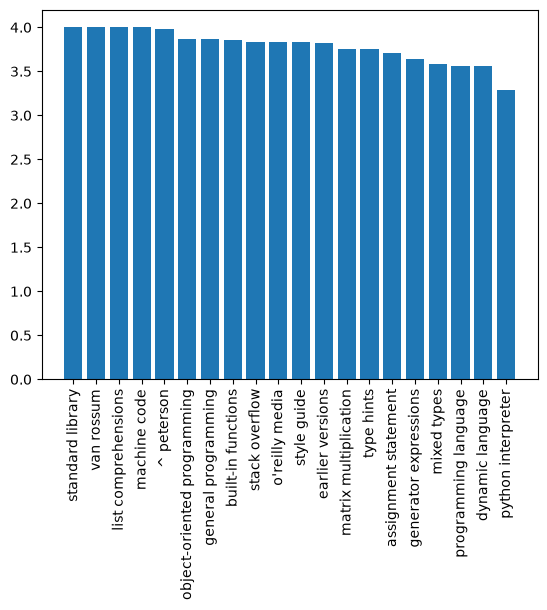

In [31]:
plot(top_res2)

In [34]:
from wordcloud import WordCloud

In [35]:
wc_object = WordCloud(background_color = 'white', width = 800, height = 500)

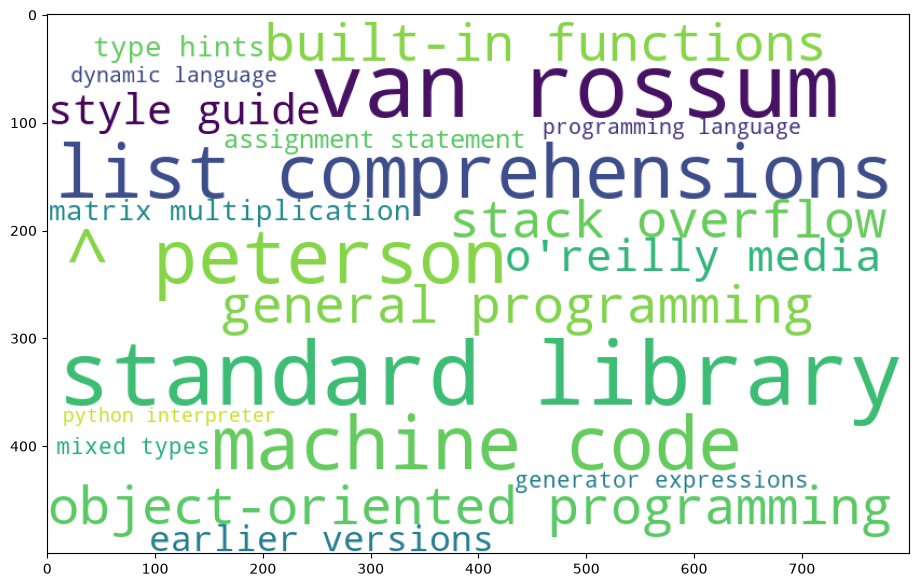

In [36]:
plt.figure(figsize=(15, 7))
# result = wc_object.generate(text)
plt.imshow(wc_object.generate_from_frequencies({ k:v for k, v in top_res }))

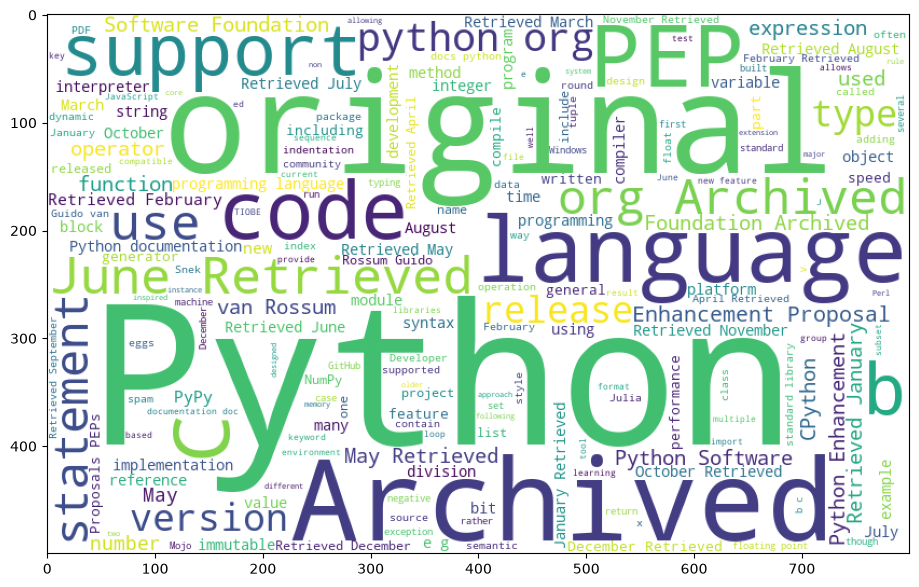

In [37]:
plt.figure(figsize = (15, 7))
plt.imshow(wc_object.generate(text))

In [44]:
def ploth(pair_list):
    (k, v) = zip(*pair_list)
    plt.barh(range(len(k)), v)
    plt.yticks(range(len(k)), k, rotation = 'horizontal')
    plt.show()

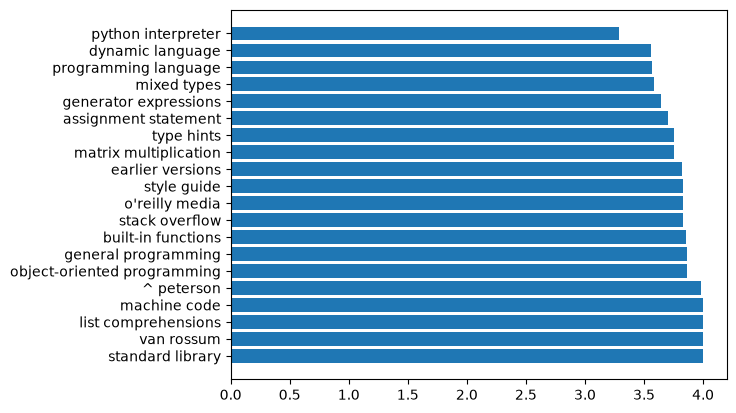

In [45]:
ploth(top_res)